In [10]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the Dataset

In [221]:
df= pd.read_csv(r"C:\Users\my\Downloads\supply_chain_order_fulfillment_delay_risk.csv")
df.head()

,order_id,order_date,supplier_reliability_score,warehouse_inventory_level,order_quantity,shipping_distance_km,shipping_method,weather_condition,processing_time_hours,order_priority,delayed
0,1,01-01-2023 00:00,0.63,2869,253,1822.8,Sea,Fog,15.6,Low,1
1,2,01-01-2023 01:00,0.91,2406,370,876.1,Road,Fog,53.2,Low,0
2,3,01-01-2023 02:00,0.78,4665,198,134.2,Rail,Fog,62.2,Low,0
3,4,01-01-2023 03:00,0.89,1545,363,817.9,Sea,Storm,8.2,High,0
4,5,01-01-2023 04:00,0.99,511,454,984.3,Sea,Storm,46.5,High,1


In [222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    2800 non-null   int64  
 1   order_date                  2800 non-null   object 
 2   supplier_reliability_score  2800 non-null   float64
 3   warehouse_inventory_level   2800 non-null   int64  
 4   order_quantity              2800 non-null   int64  
 5   shipping_distance_km        2800 non-null   float64
 6   shipping_method             2800 non-null   object 
 7   weather_condition           2800 non-null   object 
 8   processing_time_hours       2800 non-null   float64
 9   order_priority              2800 non-null   object 
 10  delayed                     2800 non-null   int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 240.8+ KB


In [223]:
df.describe()

,order_id,supplier_reliability_score,warehouse_inventory_level,order_quantity,shipping_distance_km,processing_time_hours,delayed
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,0.796957,2493.010357,251.872500,1014.307714,35.841071,0.291429
std,808.434702,0.115485,1408.389238,145.228533,570.653100,20.617329,0.454502
min,1.000000,0.600000,52.000000,1.000000,5.200000,1.100000,0.000000
25%,700.750000,0.700000,1309.000000,128.000000,532.950000,17.975000,0.000000
50%,1400.500000,0.790000,2459.000000,253.000000,1016.100000,35.400000,0.000000
75%,2100.250000,0.900000,3688.000000,377.000000,1508.825000,53.400000,1.000000
max,2800.000000,1.000000,4996.000000,499.000000,1998.600000,72.000000,1.000000


In [215]:
df.duplicated().sum()

np.int64(0)

In [224]:
df.head(3)

,order_id,order_date,supplier_reliability_score,warehouse_inventory_level,order_quantity,shipping_distance_km,shipping_method,weather_condition,processing_time_hours,order_priority,delayed
0,1,01-01-2023 00:00,0.63,2869,253,1822.8,Sea,Fog,15.6,Low,1
1,2,01-01-2023 01:00,0.91,2406,370,876.1,Road,Fog,53.2,Low,0
2,3,01-01-2023 02:00,0.78,4665,198,134.2,Rail,Fog,62.2,Low,0


In [225]:
df.isnull().sum()

order_id                      0
order_date                    0
supplier_reliability_score    0
warehouse_inventory_level     0
order_quantity                0
shipping_distance_km          0
shipping_method               0
weather_condition             0
processing_time_hours         0
order_priority                0
delayed                       0
dtype: int64

In [226]:
df.columns.values

array(['order_id', 'order_date', 'supplier_reliability_score',
       'warehouse_inventory_level', 'order_quantity',
       'shipping_distance_km', 'shipping_method', 'weather_condition',
       'processing_time_hours', 'order_priority', 'delayed'], dtype=object)

#Getting on to the KPIs

#1) OVERALL DELAY RATE

In [231]:
delay_rate= df["delayed"].mean()*100
print("Delay Rate in %:-", delay_rate)
if delay_rate <20:
    print("Low Risk")
elif 20 <= delay_rate <= 35:
    print("Operational Issues")
else:
    print("Serious Risk")

Delay Rate in %:- 29.142857142857142
Operational Issues


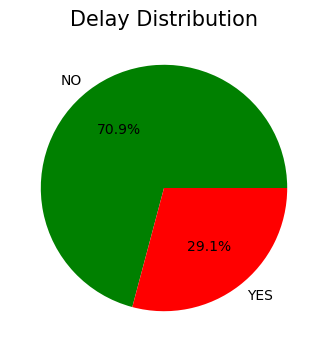

In [228]:
plt.figure(figsize=(7,4))
#ax=sns.countplot(x='delayed',data=df)
#ax.bar_label(ax.containers[0])
#plt.title("Delay Distribution",fontsize=10)
gb= df.groupby("delayed").agg({'delayed':'count'})
labels= ["NO" if x==0 else "YES" for x in gb.index]
colours=["green","red"]
plt.pie(gb['delayed'],labels=labels, autopct="%.1f%%",colors=colours)
plt.title("Delay Distribution",fontsize=15)
plt.show()

#2)ON-TIME DELIVERY RATE

In [229]:
ontime_deliveryrate= (1-df["delayed"].mean())*100
print("On-Time Delivery Rate in % :-", ontime_deliveryrate)

On-Time Delivery Rate in % :- 70.85714285714286


#3)DELAY RATE BY SHIPPING METHODS

In [252]:
delayrate_shipping= df.groupby('shipping_method')["delayed"].mean().mul(100).reset_index()
delayrate_shipping.columns=["Shipping Method","Delay Rate(%)"]
print("Delay Rate By Shipping Method")
print(delayrate_shipping)

Delay Rate By Shipping Method
  Shipping Method  Delay Rate(%)
0             Air      31.486880
1            Rail      29.687500
2            Road      26.141079
3             Sea      29.403202


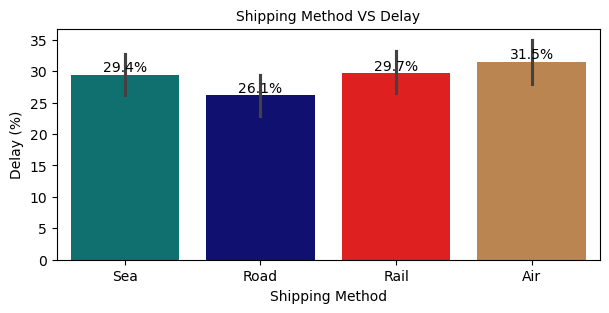

In [253]:
df["delayed_pct"]=df["delayed"]*100
plt.figure(figsize=(7,3))
colours=["teal","navy","red","peru"]
ax=sns.barplot(x="shipping_method",y="delayed_pct",data=df,palette =colours ,hue="shipping_method",legend= False)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

#ax.bar_label(ax.containers[0],fmt="%.1f%%")
ax.set_xlabel("Shipping Method")
ax.set_ylabel("Delay (%)")
plt.title("Shipping Method VS Delay",fontsize=10)
plt.show()

#4)DELAY RATE BY WEATHER CONDITIONS (Does weather affect delay?)

In [250]:
delayrate_weather= df.groupby('weather_condition')["delayed"].mean().mul(100).reset_index()
delayrate_weather.columns=["Weather Conditions","Delay Rate(%)"]
print("Delay Rate by Weather Conditions")
print(delayrate_weather)

Delay Rate by Weather Conditions
  Weather Conditions  Delay Rate(%)
0              Clear      25.000000
1                Fog      30.563003
2               Rain      29.292929
3              Storm      31.729323


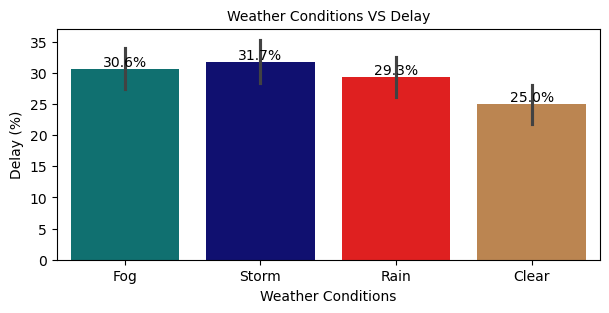

In [251]:
df['delayed_pct']= df['delayed']*100
plt.figure(figsize=(7,3))
colours=["teal","navy","red","peru"]
ax=sns.barplot(x="weather_condition",y="delayed_pct",palette=colours,hue="weather_condition", legend= False,data= df)
for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%")
ax.set_xlabel("Weather Conditions")
ax.set_ylabel("Delay (%)")
plt.title("Weather Conditions VS Delay",fontsize=10)
plt.show()

#5) DELAY RATE BY ORDER PRIORITY (Are high priority orders handled properly?)

In [249]:
delayrate_orderpriority= df.groupby('order_priority')["delayed"].mean().mul(100).reset_index()
delayrate_orderpriority.columns=["Order Priority","Delay Rate(%)"]
print("Delay Rate by Order Priority")
print(delayrate_orderpriority)

Delay Rate by Order Priority
  Order Priority  Delay Rate(%)
0           High      30.180659
1            Low      28.662420
2         Medium      28.571429


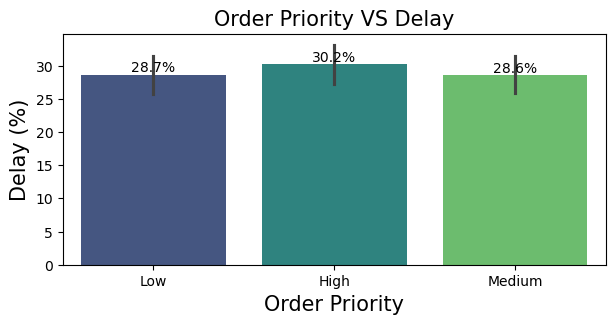

In [248]:
df['delayed_pct']= df['delayed']*100
plt.figure(figsize=(7,3))
ax=sns.barplot(x="order_priority",y="delayed_pct",palette="viridis",hue="order_priority",legend= False, data= df)
for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%")
ax.set_xlabel("Order Priority",fontsize= 15)
ax.set_ylabel("Delay (%)",fontsize= 15)
plt.title("Order Priority VS Delay",fontsize=15)
plt.show()

#6) SUPPLIER RELIABILITY VS DELAY (We can expect that lower reliability higher delay)

In [245]:
df['reliability_bucket']=pd.cut(df['supplier_reliability_score'],bins=(0.4,0.75,0.9,1),labels=['Low','Medium','High'],include_lowest=True)
delay_by_reliability= df.groupby('reliability_bucket', observed=True )["delayed"].mean().mul(100).reset_index()
delay_by_reliability.columns=["Reliability","Delay Rate(%)"]
print(delay_by_reliability)

  Reliability  Delay Rate(%)
0         Low      31.127013
1      Medium      27.686350
2        High      28.043143


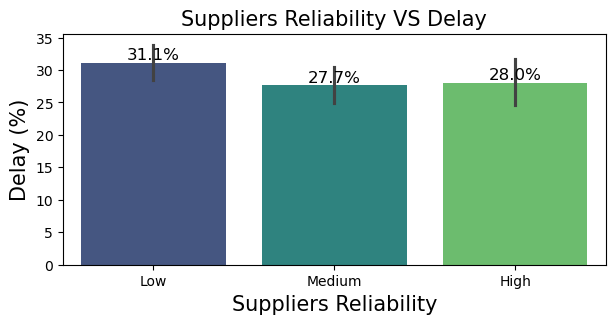

In [246]:
df['delayed_pct']= df['delayed']*100
plt.figure(figsize=(7,3))
ax=sns.barplot(x="reliability_bucket",y="delayed_pct",palette="viridis",hue="reliability_bucket",legend= False,data= df)
for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%",fontsize=12)
ax.set_xlabel("Suppliers Reliability",fontsize= 15)
ax.set_ylabel("Delay (%)",fontsize= 15)
plt.title("Suppliers Reliability VS Delay",fontsize=15)
plt.show()

#7) DISTANCE IMPACT (Does distance affecting the delay?)

In [243]:
df['distance_bucket'], bins = pd.qcut(df['shipping_distance_km'],q=4, labels=['Short Distance-(5.2 - 532.95)', 'Medium Distance-(532.95 - 1016.1)', 'Long Distance-(1016.1 - 1508.82)', 'Very Long Distance-(1508.82 - 1998.6)'], retbins=True)
print("Quartile Boundaries",bins)

delay_by_distance= df.groupby('distance_bucket', observed=True )["delayed"].mean().mul(100).reset_index()
delay_by_distance.columns=['Distance(in Km)', 'Delay(%)']
print(delay_by_distance)


Quartile Boundaries [   5.2    532.95  1016.1   1508.825 1998.6  ]
                         Distance(in Km)   Delay(%)
0          Short Distance-(5.2 - 532.95)  30.571429
1      Medium Distance-(532.95 - 1016.1)  28.142857
2       Long Distance-(1016.1 - 1508.82)  28.857143
3  Very Long Distance-(1508.82 - 1998.6)  29.000000


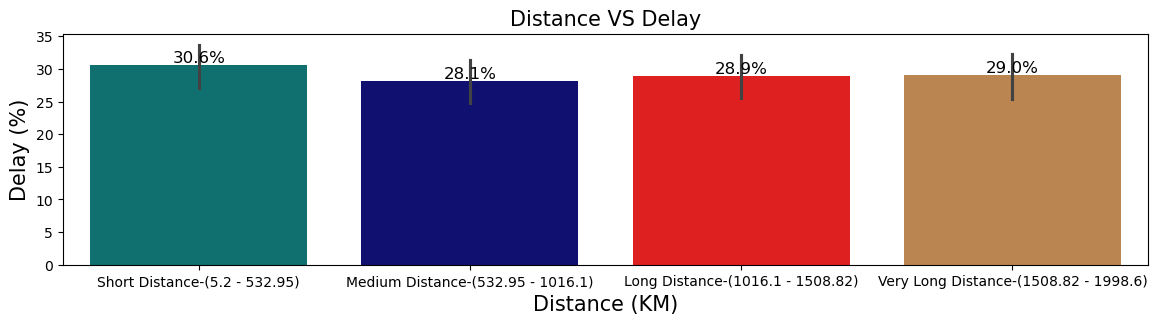

In [244]:
df['delayed_pct']= df['delayed']*100
plt.figure(figsize=(14,3))
colours=["teal","navy","red","peru"]
ax=sns.barplot(x="distance_bucket",y="delayed_pct",palette=colours,hue="distance_bucket",legend= False, data= df)
for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%",fontsize=12)
ax.set_xlabel("Distance (KM)",fontsize= 15)
ax.set_ylabel("Delay (%)",fontsize= 15)
plt.title("Distance VS Delay",fontsize=15)
plt.show()

#8) INVENTORY IMPACT( Does low inventory result to delays?)

In [242]:
label=['Low Inventory','Medium Inventory','High Inventory','Very High Inventory']
df['inventory_bucket'],bins= pd.qcut(df['warehouse_inventory_level'],q=4,labels=label,retbins=True)
print("Quartile Boundaries:", bins)
delayrate_inventory= df.groupby('inventory_bucket', observed=True)["delayed"].mean().mul(100).reset_index()
print(delayrate_inventory)
print("Inventory segmentation into quartiles showed minimal variation in delay rates(28–30%),Warehouse inventory level is not a strong factor of delays in this data.")

Quartile Boundaries: [  52. 1309. 2459. 3688. 4996.]
      inventory_bucket    delayed
0        Low Inventory  28.815977
1     Medium Inventory  29.671897
2       High Inventory  30.085960
3  Very High Inventory  28.000000
Inventory segmentation into quartiles showed minimal variation in delay rates(28–30%),Warehouse inventory level is not a strong factor of delays in this data.


#9) PROCESSING TIME IMPACT

In [239]:
label=['Low Processing Time','Medium Processing Time','High Processing Time','Very High Processing Time']
df['processing_time_bucket'],bins= pd.qcut(df['processing_time_hours'],q=4,labels=label,retbins=True)
print("Quartile Boundaries:", bins)
delayrate_processing= df.groupby('processing_time_bucket', observed=True)["delayed"].mean().mul(100).reset_index()
delayrate_processing.columns=['Processing Time(in Hr)', 'Delay(%)']
print(delayrate_processing)

Quartile Boundaries: [ 1.1   17.975 35.4   53.4   72.   ]
      Processing Time(in Hr)   Delay(%)
0        Low Processing Time  26.285714
1     Medium Processing Time  29.829545
2       High Processing Time  29.428571
3  Very High Processing Time  31.034483


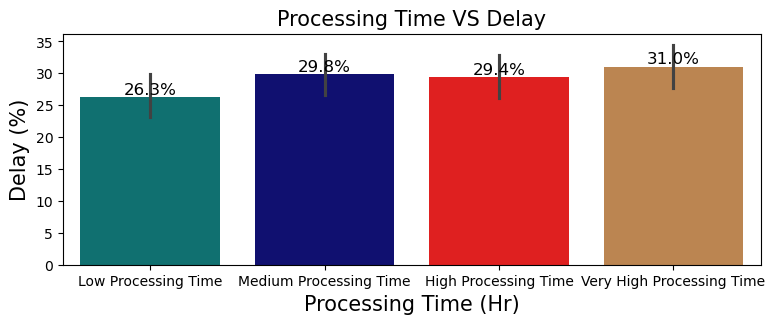

In [241]:
df['delayed_pct']= df['delayed']*100
plt.figure(figsize=(9,3))
colours=["teal","navy","red","peru"]
ax=sns.barplot(x="processing_time_bucket",y="delayed_pct",palette=colours,hue="processing_time_bucket",legend= False, data= df)
for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%",fontsize=12)
ax.set_xlabel("Processing Time (Hr)",fontsize= 15)
ax.set_ylabel("Delay (%)",fontsize= 15)
plt.title("Processing Time VS Delay",fontsize=15)
plt.show()

#10) ORDER QUANTITY IMPACT

In [234]:
label=['Small Order','Medium Order','Big Order','Very Big Order']
df['order_bucket'],bins= pd.qcut(df['order_quantity'],q=4,labels=label,retbins=True)
print("Quartile Boundaries:", bins)
delayrate_orders= df.groupby('order_bucket', observed=True)["delayed"].mean().mul(100).reset_index()
delayrate_orders.columns=['Orders', 'Delay(%)']
print(delayrate_orders)
print("As the order size increases the delay rate decreases. Smaller orders are slightly more likely to be delayed.")

Quartile Boundaries: [  1. 128. 253. 377. 499.]
           Orders   Delay(%)
0     Small Order  30.626781
1    Medium Order  29.243937
2       Big Order  28.632479
3  Very Big Order  28.057554
As the order size increases the delay rate decreases. Smaller orders are slightly more likely to be delayed.


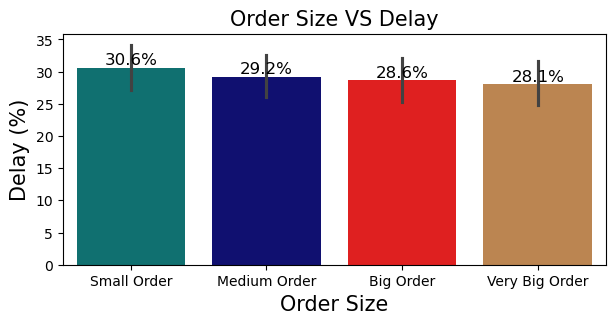

In [235]:
df['delayed_pct']= df['delayed']*100
plt.figure(figsize=(7,3))
colours=["teal","navy","red","peru"]
ax=sns.barplot(x="order_bucket",y="delayed_pct",palette=colours,hue="order_bucket",legend= False, data= df)
for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%",fontsize=12)
ax.set_xlabel("Order Size",fontsize= 15)
ax.set_ylabel("Delay (%)",fontsize= 15)
plt.title("Order Size VS Delay",fontsize=15)
plt.show()

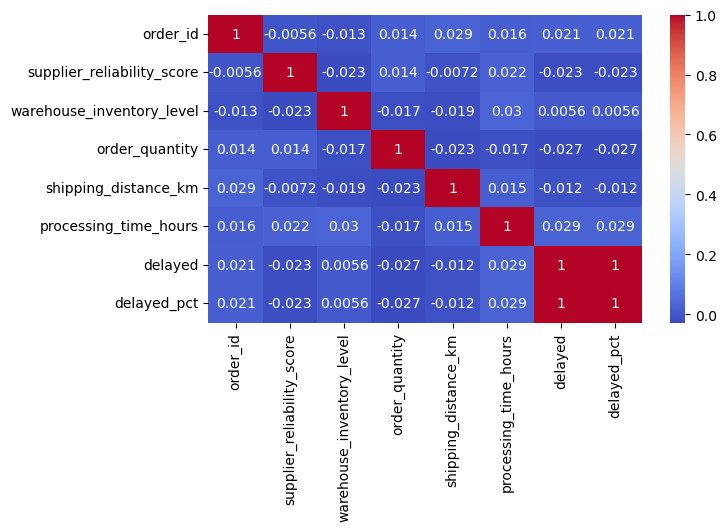

In [237]:
plt.figure(figsize=(7,4))
sns.heatmap(df.select_dtypes(include="number").corr(),annot=True,cmap="coolwarm")
plt.show()